<!-- ### imports -->

In [1]:
import sys
sys.path.append('../')
sys.path.append('./')
import dill
dill.settings['recurse'] = True
import os

import xgboost as xgb
from utils.helper_functions import (
    read_csv_incl_timeindex,
    plot_dependency, 
    read_csv_incl_timeindex, 
    get_color, 
    draw,
    calculate_correlation
)
from utils.feature_configuration import edges_FR_price, edges_FR_export, edges_ES_price, paper_rename_dict_including_units, list_target_nodes

In [2]:
import matplotlib
import matplotlib.image as mpimg
matplotlib.rcParams['pgf.texsystem'] = 'pdflatex'
matplotlib.rcParams.update({'font.family': 'serif', 'font.size': 16,
    'axes.labelsize': 16,'axes.titlesize': 16, 'figure.titlesize' : 18})
matplotlib.rcParams['text.usetex'] = True 
import matplotlib.pyplot as plt

# Set global font sizes
plt.rcParams['axes.titlesize'] = 16       # For axes titles
plt.rcParams['axes.labelsize'] = 16       # For x and y labels
plt.rcParams['legend.fontsize'] = 16      # For legend text
plt.rcParams['figure.titlesize'] = 18     # For suptitle (figure title)
plt.rcParams['xtick.labelsize'] = 16
plt.rcParams['ytick.labelsize'] = 16

from matplotlib.colors import LogNorm

In [3]:
figure_folder = "../figs_for_paper/"
if os.path.exists(figure_folder):
    print(f"Figure folder '{figure_folder}' already exists.")
else:
    os.makedirs(figure_folder)
    print(f"Figure folder '{figure_folder}' created.")

Figure folder '../figs_for_paper/' already exists.


# Load credit flow and models

In [4]:
creditflow_dict = {}
model_dict = {}
fg_dict = {}
bg_dict = {}

graph_dict = {}
target_names = []
periods = [('2018-01-01', '2023-12-31')]


countries = ['FR', 'ES']
for country in countries:
    if country == 'FR':
        targets = ['FR_price', 'FR_export'] 
        other_country = 'ES'
    elif country == 'ES':
        targets = ['ES_price']
        other_country = 'FR'
        edges = edges_ES_price
    for target in targets:
        target_names.append(target)
        if (country == 'FR') and (target == 'FR_price'):
            edges = edges_FR_price
        elif (country == 'FR') and (target == 'FR_export'):
            edges = edges_FR_export
        for start_date, end_date in periods:
            model_name = 'xgb_{}_start_{}_end_{}_best'.format(target, start_date, end_date)
            cf_file_name = 'flow_xgb_{}_start_{}_end_{}'.format(target, start_date, end_date)
            with open('../credit_flow/{}.pkl'.format(cf_file_name), 'rb') as file:
                loaded_cf = dill.load(file, )
                creditflow_dict[target] = loaded_cf

            model = xgb.Booster()
            
            model.load_model("../models/{}.json".format(model_name))
            model_dict[target] = model


            fg_dict[target] = read_csv_incl_timeindex('../credit_flow/fg_xgb_{}_start_{}_end_{}.csv'.format(target, start_date, end_date))
            bg_dict[target] = read_csv_incl_timeindex('../credit_flow/bg_xgb_{}_start_{}_end_{}.csv'.format(target, start_date, end_date))

            # for  plotting the pure causal graphs without edge attribution
            graph_name = 'xgb_{}_start_{}_end_{}'.format(target, start_date, end_date)
            with open('../credit_flow/causal_graph_{}.pkl'.format(graph_name), 'rb') as file:
                causal_graph = dill.load(file)
                graph_dict[target] = causal_graph

# Plot the causal graphs

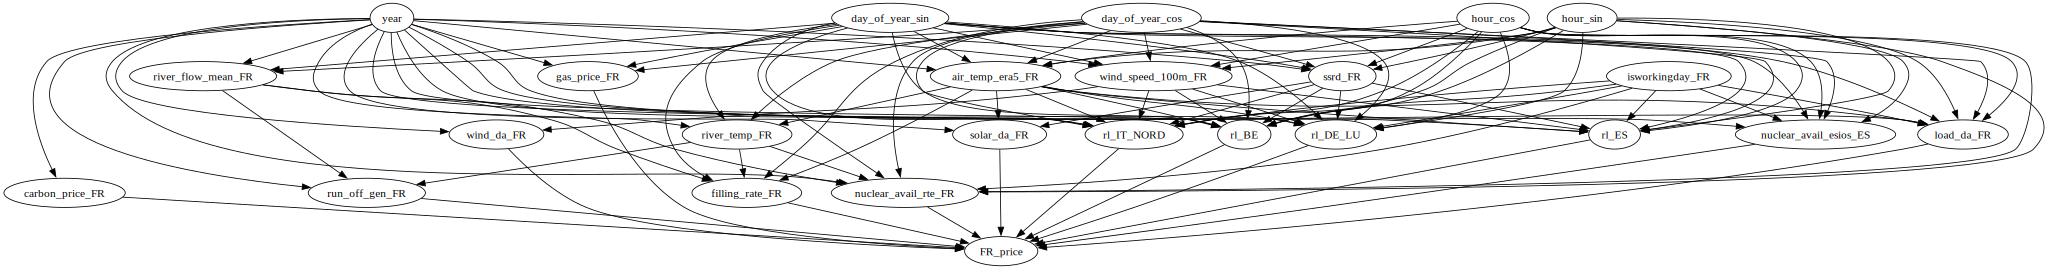

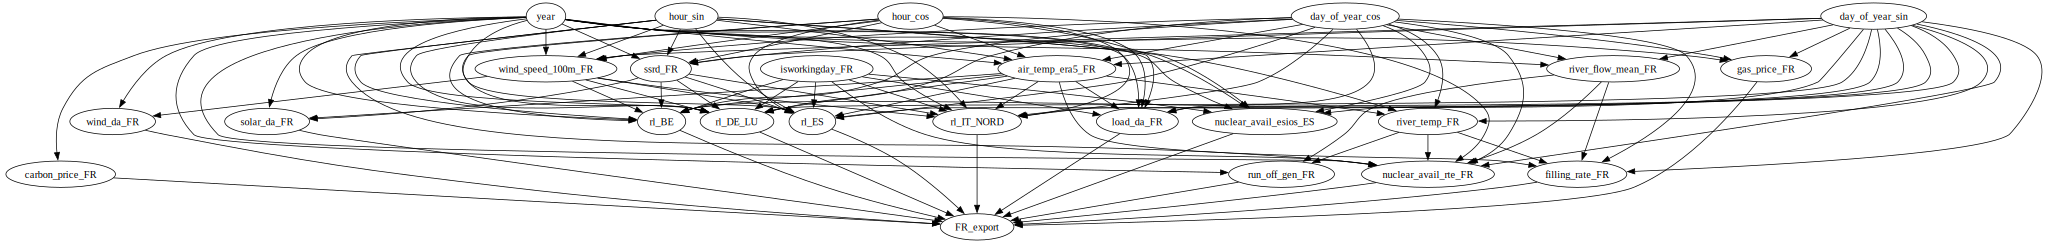

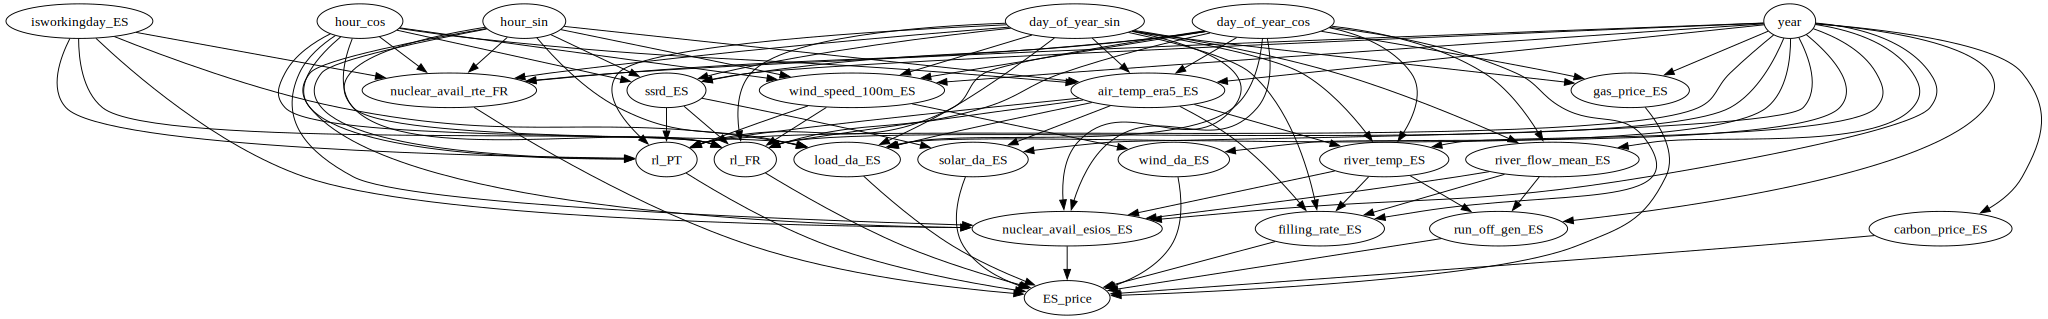

In [5]:
for key in graph_dict.keys():
    graph_dict[key].draw(rankdir = 'TB')

# Shapley flow analysis

### Calculate correlation of feature nodes and Shapley flow values in order to find the suitable color for the graph plots

In [6]:
for show_edges_to_target in [True, False]:
    if show_edges_to_target:
        correlation_dict = {}
        for target in target_names:
            correlation_dict[target] = {}
            target_node = target
            cf = creditflow_dict[target]
            fg_values = fg_dict[target]
            for node1, d in cf.edge_credit.items():
                if target_node in [node2.name for node2 in d.keys()]:
                    corr = calculate_correlation(node1.name, target_node, cf, fg_values)
                    correlation_dict[target]['{}-{}'.format(node1.name, target_node)] = corr

    elif not show_edges_to_target:
        correlation_dict_intermediate = {}
        for target in target_names[0:]:
            correlation_dict_intermediate[target] = {}
            list_target_selected = []
            cf = creditflow_dict[target]
            fg_values = fg_dict[target]
            length_targets = 0
            max_length_parents = 0
            for target_node in list_target_nodes:
                length_parents = 0
                for node1, d in cf.edge_credit.items():
                    if node1.name in fg_values.columns:
                        if target_node in [node2.name for node2 in d.keys()]:
                            length_parents += 1
                if length_parents > max_length_parents:
                    max_length_parents = length_parents
                if length_parents > 0:
                    length_targets += 1
                    list_target_selected.append(target_node)


            for target_node in list_target_selected: 
                for node1, d in cf.edge_credit.items():
                    if node1.name in fg_values.columns:
                        if target_node in [node2.name for node2 in d.keys()]:
                            corr = calculate_correlation(node1.name, target_node, cf, fg_values)
                            correlation_dict_intermediate[target]['{}-{}'.format(node1.name, target_node)] = corr
        

correlation_dict_combined = {}
for target in target_names[:]:
    dict1 = correlation_dict[target].copy()
    dict2 = correlation_dict_intermediate[target].copy()
    correlation_dict_combined[target] = {**dict1, **dict2}
with open('../results/correlation_dict_combined.pkl', 'wb') as file:
    dill.dump(correlation_dict_combined, file)

### Plots of mean absolute credit (Figure 5 and Suppl. Figures 7 and 9)

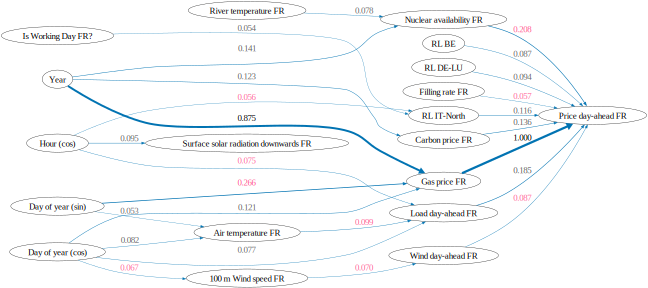

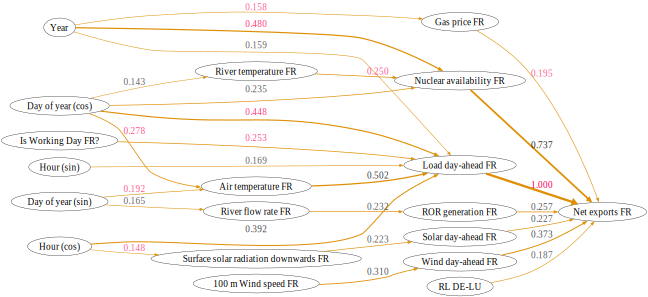

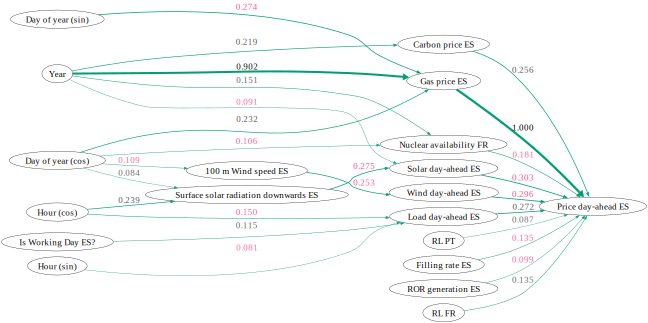

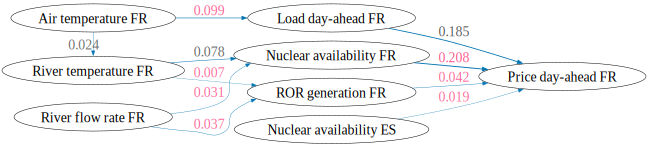

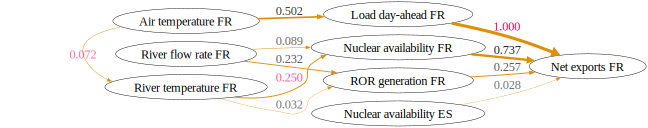

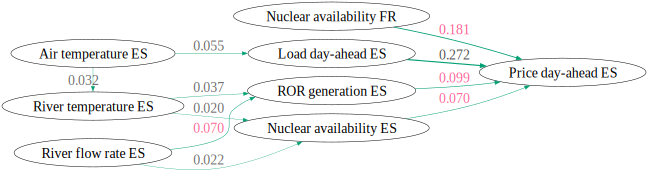

In [7]:
with open('../results/correlation_dict_combined.pkl', 'rb') as file:
    correlation_dict_combined = dill.load(file)

show_mean_abs = True

for show_only_some_feature_selection in [False, True]:
    if show_only_some_feature_selection:
        max_display = -1
        flow_dict_feature_selection = {}
    else:
        max_display = 25
        flow_dict = {}

    for key in creditflow_dict.keys():
        creditflow_dict[key].fold_noise=True
        if show_mean_abs:
            idx = -1
            dot = draw(idx=-1, show_fg_val=True, max_display=max_display, edge_credit = creditflow_dict[key].edge_credit, 
                rankdir = 'LR', fold_noise=True, color=get_color(key), 
                dict_correlation_for_color = correlation_dict_combined[key],
                format_str="{:.3f}", show_only_some_feature_selection=show_only_some_feature_selection)
            
        else:
            # in the case of plotting the causal graph for certain samples, we use the original plotting function without the correlation-based coloring
            g = creditflow_dict[key].draw(idx=-1,
                        show_fg_val=True,
                        max_display=max_display,
                        edge_credit = creditflow_dict[key].edge_credit)
            start_date, end_date = periods[0]
            g.graph_attr['rankdir']='LR'
        if show_only_some_feature_selection:
            flow_dict_feature_selection[key] = dot
            flow_dict_feature_selection[key].draw('../figs_for_paper/flow_mean-abs_normalized-{}_partial_graph.pdf'.format(key), format='pdf')
        else:
            flow_dict[key] = dot
            flow_dict[key].draw('../figs_for_paper/flow_mean-abs_normalized-{}_{}_edges_full_graph.pdf'.format(key, max_display), format='pdf')

# Plot the dependencies plots

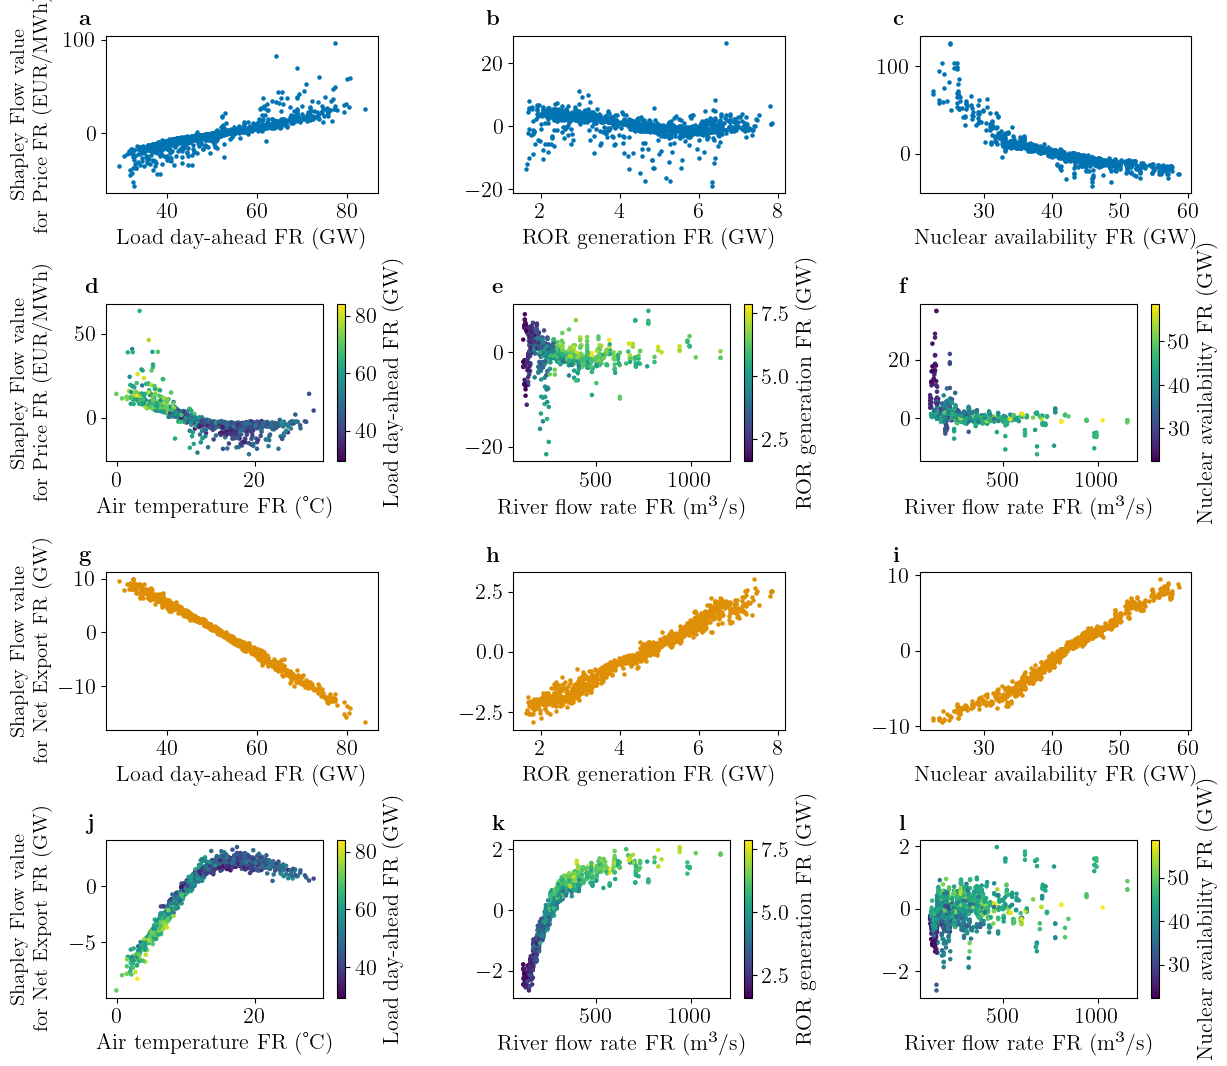

In [ ]:
fig,ax = plt.subplots(4, 3, figsize=(14, 13))
indirect_nodes = ['air_temp_era5_FR', 'river_flow_mean_FR', 'river_flow_mean_FR']
nodes_intermediate = ['load_da_FR', 'run_off_gen_FR', 'nuclear_avail_rte_FR']

for i, target in enumerate(['FR_price', 'FR_export']):
    cf = creditflow_dict[target]
    fg_values = fg_dict[target]
    if target == 'FR_price':
        scale_y = 1
    else:
        scale_y = 1000
    target_node = target
    for j, node1_name in enumerate(nodes_intermediate):
        if paper_rename_dict_including_units[node1_name][-4:] == '(GW)':
            scale_x = 1000
        else:
            scale_x = 1
        corr = plot_dependency(node1_name, target_node, cf, fg_values, color=None, 
                        x_label='', color_label=target_node, scale_color=None, 
                        scale_x=scale_x, scale_y = scale_y, axes=ax[2*i,j], fig = fig)
        
    for j, target_node in enumerate(nodes_intermediate):
        node1_name = indirect_nodes[j]
        if paper_rename_dict_including_units[node1_name][-4:] == '(GW)':
            scale_x = 1000
        else:
            scale_x = 1
        if paper_rename_dict_including_units[target_node][-4:] == '(GW)':
            scale_color = 1000
        else:
            scale_color = 1    
        corr = plot_dependency(node1_name, target_node, cf, fg_values, color=None, 
                        x_label='', color_label=target_node, scale_color=scale_color, 
                        scale_x=scale_x, scale_y = scale_y, axes=ax[2*i+1,j], fig = fig)

ax[0,0].set_ylabel('Shapley Flow value \nfor Price FR (EUR/MWh)', fontsize=15)
ax[1,0].set_ylabel('Shapley Flow value \nfor Price FR (EUR/MWh)', fontsize=15)
ax[2,0].set_ylabel('Shapley Flow value \nfor Net Export FR (GW)', fontsize=15)
ax[3,0].set_ylabel('Shapley Flow value \nfor Net Export FR (GW)', fontsize=15)
fig.align_ylabels(ax[:,0])

panel_label_ls = [r"\textbf{a}", r"\textbf{b}", r"\textbf{c}", 
                  r"\textbf{d}", r"\textbf{e}", r"\textbf{f}", 
                  r"\textbf{g}", r"\textbf{h}", r"\textbf{i}", 
                  r"\textbf{j}", r"\textbf{k}", r"\textbf{l}"]
shift = -.1
for idx_r, ax_r in enumerate(ax.flatten()):
    ax_r.text(0 + shift, 1.1, panel_label_ls[idx_r],
                weight='bold', verticalalignment='center',
                transform=ax_r.transAxes)

fig.subplots_adjust(wspace=0.5, hspace=0.7, top=0.85)
fig.savefig("../figs_for_paper/dependency_edges_between_features_FR.pdf", bbox_inches='tight')

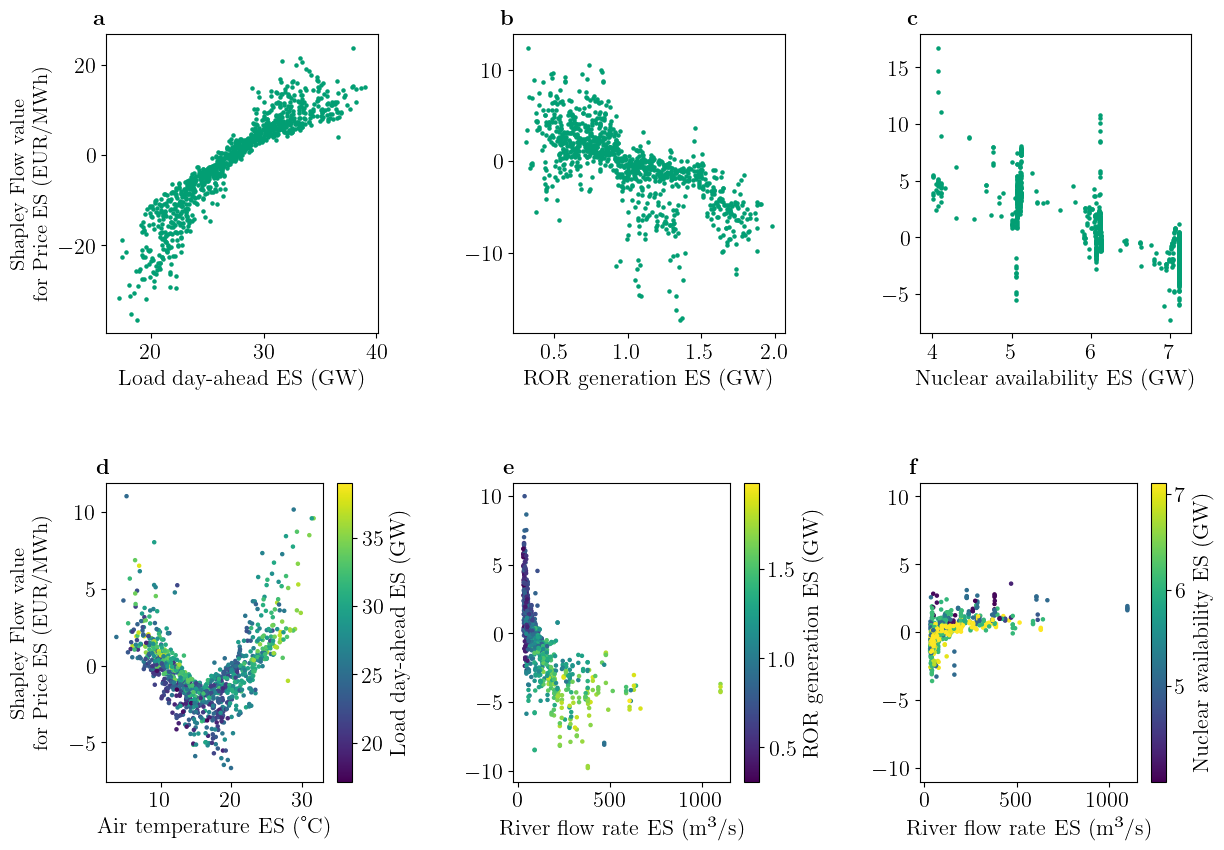

In [ ]:
fig,ax = plt.subplots(2, 3, figsize=(14, 6.5))
indirect_nodes = ['air_temp_era5_ES', 'river_flow_mean_ES', 'river_flow_mean_ES']
nodes_intermediate = ['load_da_ES', 'run_off_gen_ES', 'nuclear_avail_esios_ES']

for i, target in enumerate(['ES_price']):
    scale_y = 1
    cf = creditflow_dict[target]
    fg_values = fg_dict[target]

    target_node = target
    for j, node1_name in enumerate(nodes_intermediate):
        if paper_rename_dict_including_units[node1_name][-4:] == '(GW)':
            scale_x = 1000
        else:
            scale_x = 1
        corr = plot_dependency(node1_name, target_node, cf, fg_values, color=None,
                        x_label='', color_label=target_node, scale_color=None, 
                        scale_x=scale_x, scale_y=scale_y, axes=ax[2*i,j], fig =fig)
        
    for j, target_node in enumerate(nodes_intermediate):
        node1_name = indirect_nodes[j]
        if paper_rename_dict_including_units[node1_name][-4:] == '(GW)':
            scale_x = 1000
        else:
            scale_x = 1
        if paper_rename_dict_including_units[target_node][-4:] == '(GW)':
            scale_color = 1000
        else:
            scale_color = 1    
        corr = plot_dependency(node1_name, target_node, cf, fg_values, color=None,
                        x_label='', color_label=target_node, scale_color=scale_color, 
                        scale_x=scale_x, scale_y=scale_y, axes=ax[2*i+1,j], fig =fig)
ax[1,2].set_ylim(-11,11)
ax[0,0].set_ylabel('Shapley Flow value \nfor Price ES (EUR/MWh)', fontsize=15)
ax[1,0].set_ylabel('Shapley Flow value \nfor Price ES (EUR/MWh)', fontsize=15)
fig.align_ylabels(ax[:,0])

panel_label_ls = [r"\textbf{a}", r"\textbf{b}", r"\textbf{c}", 
                  r"\textbf{d}", r"\textbf{e}", r"\textbf{f}", 
                  r"\textbf{g}", r"\textbf{h}", r"\textbf{i}", 
                  r"\textbf{j}", r"\textbf{k}", r"\textbf{l}"]
shift = -.05
for idx_r, ax_r in enumerate(ax.flatten()):
    ax_r.text(0 + shift, 1.05, panel_label_ls[idx_r],
                weight='bold', verticalalignment='center',
                transform=ax_r.transAxes)

fig.subplots_adjust(wspace=0.5, hspace=0.5, top=1.2, bottom=0.05)
file_name = figure_folder + "dependency_edges_between_features_ES.pdf"
fig.savefig(file_name, bbox_inches='tight')

<!-- ### model 0: Janury 2015 - September 2021 -->